<a href="https://colab.research.google.com/github/tndhrthwls12/Gangdong-infographic26/blob/main/%EC%82%AC%EA%B3%A0_%EC%98%88%EC%B8%A1_%EB%B3%B4%EA%B3%A0%EC%84%9C_%ED%81%B4%EB%A1%9C%EB%93%9Cver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 섹션 1 : 사고데이터(CSV) 업로드 및 정리
# 아래 4개 블록(1-1 ~ 1-4)을 각각 별도의 코랩 코드 셀에 붙여넣으세요.
# 셀을 나눠두면 나중에 특정 부분만 수정하기 편합니다.
# ============================================================


# ------------------------------------------------------------
# 1-1. CSV 파일 업로드
# 실행하면 "파일 선택" 버튼이 나타납니다. 매주 받는 CSV 파일을 그대로 첨부하세요.
# ------------------------------------------------------------
from google.colab import files
import pandas as pd

print("사고분석 CSV 파일을 업로드해주세요.")
uploaded = files.upload()
csv_filename = list(uploaded.keys())[0]

df_raw = pd.read_csv(csv_filename)
print(f"\n'{csv_filename}' 파일을 불러왔습니다. (원본 {len(df_raw)}행)")


# ------------------------------------------------------------
# 1-2. 필요한 컬럼만 선택 + 중복/이상 데이터 정리
# A,B,C,D,R,S,T,U 열만 남기고, 혹시 있을 중복 행을 제거합니다.
# ------------------------------------------------------------
필요_컬럼 = ['예측일자', '역명_정리', '시간대', '요일구분',
          '예측주요유형', '위험점수', '위험등급', '위험요인']

df = df_raw[필요_컬럼].copy()

# 같은 역인데 표기가 다른 경우, 하나의 이름으로 통일
# (CSV에 새로운 역이 이런 형태로 추가되면 아래 딕셔너리에 한 줄만 추가하면 됩니다)
역명_통일 = {
    '굽은다리(강동구민회관앞)': '굽은다리',
    '올림픽공원(한국체대)': '올림픽공원',
}
df['역명_정리'] = df['역명_정리'].replace(역명_통일)

# 완전히 동일한 행이 중복되어 있으면 하나만 남김
df = df.drop_duplicates()

# 같은 날짜+같은 역인데 값이 여러 개면(위 통일 과정 + 데이터 오류 대비 안전장치),
# 위험점수가 더 높은 행 하나만 남김
df = (df.sort_values('위험점수', ascending=False)
        .drop_duplicates(subset=['예측일자', '역명_정리'], keep='first'))

df['예측일자'] = pd.to_datetime(df['예측일자'])
df = df.sort_values(['예측일자', '위험점수'], ascending=[True, False]).reset_index(drop=True)

print(f"정리 완료: {len(df)}행 / 역 {df['역명_정리'].nunique()}개 / 일자 {df['예측일자'].nunique()}개")
df.head(8)


# ------------------------------------------------------------
# 1-3. 인포그래픽1용 데이터 만들기  →  data_info1
# 일자별로: 위험등급(최고 1개) + 위험점수 상위 3개 역(사고유형/시간대 포함)
# ------------------------------------------------------------
등급_순위 = {'매우높음': 4, '높음': 3, '보통': 2, '낮음': 1}

data_info1 = []
for 날짜, 그룹 in df.groupby('예측일자'):
    top3 = 그룹.sort_values('위험점수', ascending=False).head(3)
    대표등급 = 그룹.loc[그룹['위험등급'].map(등급_순위).idxmax(), '위험등급']

    data_info1.append({
        '일자': 날짜.strftime('%m.%d'),
        '요일': 그룹['요일구분'].iloc[0],
        '위험등급': 대표등급,
        '상위역': [
            {
                '역명': r['역명_정리'],
                '사고유형': r['예측주요유형'],
                '시간대': r['시간대'],
                '위험점수': r['위험점수'],
            }
            for _, r in top3.iterrows()
        ],
    })

print(f"인포그래픽1용 데이터 {len(data_info1)}일치 준비 완료\n")
print("예시(첫째 날):")
data_info1[0]


# ------------------------------------------------------------
# 1-4. 인포그래픽2용 데이터 만들기  →  data_info2
# 역별로 위험점수가 가장 높은 시점(=그 역의 대표 위험 상황) 1건씩 추출
# 위험요인은 최대 2줄, 한 줄당 약 15자로 요약
# 역 순서는 위험점수순이 아니라, 정해진 역 순서(노선 순서)로 고정 배치
# ------------------------------------------------------------
def 위험요인_2줄로_정리(원문, 한줄최대글자=15):
    """쉼표로 나열된 위험요인 문구들을, 앞에서부터 채워 최대 2줄로 요약합니다.
    한 줄에 다 안 들어가는 나머지 문구는 생략됩니다."""
    항목들 = [x.strip() for x in 원문.split(',')]
    line1, line2 = '', ''
    for 항목 in 항목들:
        if len(line1) == 0:
            line1 = 항목
        elif len(line1) + len(항목) + 2 <= 한줄최대글자:
            line1 += ', ' + 항목
        elif len(line2) == 0:
            line2 = 항목
        elif len(line2) + len(항목) + 2 <= 한줄최대글자:
            line2 += ', ' + 항목
        else:
            break
    return line1, line2


data_info2 = []
for 역명, 그룹 in df.groupby('역명_정리'):
    최고위험행 = 그룹.loc[그룹['위험점수'].idxmax()]
    줄1, 줄2 = 위험요인_2줄로_정리(최고위험행['위험요인'])

    data_info2.append({
        '역명': 역명,
        '시간대': 최고위험행['시간대'],
        '요일': 최고위험행['요일구분'],
        '사고유형': 최고위험행['예측주요유형'],
        '위험점수': 최고위험행['위험점수'],
        '위험등급': 최고위험행['위험등급'],
        '위험요인_줄1': 줄1,
        '위험요인_줄2': 줄2,
    })

# 인포그래픽2는 위험점수순이 아니라, 정해진 역 순서(노선 순서)로 고정 배치
역_순서 = [
    '강동', '길동', '굽은다리', '명일', '고덕', '상일동', '둔촌동',
    '올림픽공원', '방이', '개롱', '거여', '마천', '강일', '미사',
    '하남풍산', '하남시청', '하남검단산',
]
data_info2 = sorted(data_info2, key=lambda x: 역_순서.index(x['역명']))


print(f"인포그래픽2용 데이터 {len(data_info2)}개 역 준비 완료 (정해진 순서로 정렬됨)\n")
print("예시(순서상 첫 번째 역):")
data_info2[0]

사고분석 CSV 파일을 업로드해주세요.


Saving seven_day_station_daily_prediction.csv to seven_day_station_daily_prediction.csv

'seven_day_station_daily_prediction.csv' 파일을 불러왔습니다. (원본 126행)
정리 완료: 119행 / 역 17개 / 일자 7개
인포그래픽1용 데이터 7일치 준비 완료

예시(첫째 날):
인포그래픽2용 데이터 17개 역 준비 완료 (정해진 순서로 정렬됨)

예시(순서상 첫 번째 역):


{'역명': '강동',
 '시간대': np.int64(8),
 '요일': '수요일',
 '사고유형': '출입문끼임',
 '위험점수': np.float64(100.0),
 '위험등급': '매우높음',
 '위험요인_줄1': '역별 사고이력 높음',
 '위험요인_줄2': '수요일 해당 역 사고이력 높음'}

In [ ]:
# ============================================================
# 섹션 2 : 날씨 정보 자동 수집 (깃허브) + 누락분만 수기 입력 + final_info1 제작
# 아래 2개 블록(2-1, 2-2)을 각각 별도의 코랩 코드 셀에 붙여넣으세요.
# ※ 섹션 1(1-1~1-4)을 먼저 실행해서 data_info1이 만들어진 상태여야 합니다.
# ============================================================


# ------------------------------------------------------------
# 2-1. 깃허브에서 날씨 CSV 불러오기 + data_info1 날짜와 비교
# ------------------------------------------------------------
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

날짜_목록 = [항목['일자'] for 항목 in data_info1]

# 기상청에서 사용하는 공식 날씨명 목록 (누락분 수기 입력 시 드롭다운에 사용)
허용_날씨명 = [
    '맑음', '구름조금', '구름많음', '흐림',
    '소나기', '비', '눈',
    '가끔 비', '한때 비', '가끔 눈', '한때 눈',
    '비 또는 눈', '눈 또는 비',
    '천둥번개', '연무', '안개', '황사',
]

CSV_주소 = "https://raw.githubusercontent.com/tndhrthwls12/Gangdong-infographic26/main/weather-data/weather_7days.csv"

# 일자 컬럼은 반드시 문자열로 읽어야 "09.20" 같은 표기가 숫자로 잘못 바뀌지 않습니다
날씨_원본 = pd.read_csv(CSV_주소, dtype={"일자": str})

날씨_딕셔너리 = {}
for _, 행 in 날씨_원본.iterrows():
    날씨_딕셔너리[행["일자"]] = {
        "오전날씨": 행["오전날씨"], "오후날씨": 행["오후날씨"],
        "최저기온": 행["최저기온"], "최고기온": 행["최고기온"],
        "오전강수확률": 행["오전강수확률"], "오후강수확률": 행["오후강수확률"],
    }

누락된_날짜 = [날짜 for 날짜 in 날짜_목록 if 날짜 not in 날씨_딕셔너리]

print(f"깃허브에서 날씨 데이터 {len(날씨_딕셔너리)}일치를 불러왔습니다.")
if 누락된_날짜:
    print(f"[확인 필요] 다음 날짜는 날씨 정보가 없어 아래 2-2 셀에서 직접 입력해야 합니다: {누락된_날짜}")
else:
    print("data_info1의 모든 날짜에 날씨 정보가 있습니다. 2-2 셀을 실행하면 바로 완성됩니다.")


# ------------------------------------------------------------
# 2-2. 누락된 날짜만 입력 화면 표시 (없으면 바로 final_info1 완성)
# ------------------------------------------------------------

def _데이터_합치기(전체_날씨_딕셔너리):
    """data_info1 + 날씨 데이터를 합쳐 final_info1을 만듭니다."""
    global final_info1
    final_info1 = []
    for 항목 in data_info1:
        날씨 = 전체_날씨_딕셔너리[항목["일자"]]
        합쳐진_항목 = dict(항목)
        합쳐진_항목.update(날씨)
        final_info1.append(합쳐진_항목)
    print(f"완료! 인포그래픽1용 최종 데이터 {len(final_info1)}일치가 준비되었습니다.\n")
    print("예시(첫째 날):")
    print(final_info1[0])


if not 누락된_날짜:
    # 누락된 날짜가 없으면 입력창 없이 바로 완성
    _데이터_합치기(날씨_딕셔너리)

else:
    # 누락된 날짜만 골라서 입력 화면 표시 (기존 위젯과 동일한 양식)
    위젯_모음 = {}
    날짜별_화면 = []

    for 날짜 in 누락된_날짜:
        오전날씨_위젯 = widgets.Dropdown(
            options=['(선택하세요)'] + 허용_날씨명, description='오전날씨',
            style={'description_width': '80px'})
        오후날씨_위젯 = widgets.Dropdown(
            options=['(선택하세요)'] + 허용_날씨명, description='오후날씨',
            style={'description_width': '80px'})
        최저기온_위젯 = widgets.BoundedIntText(
            value=15, min=-30, max=50, description='최저기온(℃)',
            style={'description_width': '80px'})
        최고기온_위젯 = widgets.BoundedIntText(
            value=25, min=-30, max=50, description='최고기온(℃)',
            style={'description_width': '80px'})
        오전강수확률_위젯 = widgets.BoundedIntText(
            value=0, min=0, max=100, description='오전강수(%)',
            style={'description_width': '80px'})
        오후강수확률_위젯 = widgets.BoundedIntText(
            value=0, min=0, max=100, description='오후강수(%)',
            style={'description_width': '80px'})

        위젯_모음[날짜] = {
            '오전날씨': 오전날씨_위젯, '오후날씨': 오후날씨_위젯,
            '최고기온': 최고기온_위젯, '최저기온': 최저기온_위젯,
            '오전강수확률': 오전강수확률_위젯, '오후강수확률': 오후강수확률_위젯,
        }

        날짜_라벨 = widgets.HTML(f"<b>{날짜}</b> (깃허브 자료 없음)")
        한_날짜_박스 = widgets.VBox(
            [날짜_라벨, 오전날씨_위젯, 오후날씨_위젯,
             최저기온_위젯, 최고기온_위젯, 오전강수확률_위젯, 오후강수확률_위젯],
            layout=widgets.Layout(border='1px solid #ccc', padding='10px', margin='5px'))
        날짜별_화면.append(한_날짜_박스)

    제출_버튼 = widgets.Button(description='입력 완료', button_style='success')
    결과_출력창 = widgets.Output()

    def 제출_버튼_클릭시(버튼):
        with 결과_출력창:
            clear_output()
            오류_목록 = []
            수기_입력값 = {}

            for 날짜 in 누락된_날짜:
                위젯 = 위젯_모음[날짜]
                값 = {
                    '오전날씨': 위젯['오전날씨'].value,
                    '오후날씨': 위젯['오후날씨'].value,
                    '최고기온': 위젯['최고기온'].value,
                    '최저기온': 위젯['최저기온'].value,
                    '오전강수확률': 위젯['오전강수확률'].value,
                    '오후강수확률': 위젯['오후강수확률'].value,
                }
                if 값['오전날씨'] == '(선택하세요)':
                    오류_목록.append(f"{날짜}: 오전날씨를 선택해주세요")
                if 값['오후날씨'] == '(선택하세요)':
                    오류_목록.append(f"{날짜}: 오후날씨를 선택해주세요")
                if 값['최저기온'] > 값['최고기온']:
                    오류_목록.append(f"{날짜}: 최저기온이 최고기온보다 높습니다")
                수기_입력값[날짜] = 값

            if 오류_목록:
                print("[확인 필요] 아래 항목을 확인해주세요:")
                for 오류 in 오류_목록:
                    print(" -", 오류)
                return

            # 깃허브에서 불러온 데이터 + 수기 입력한 누락분을 합쳐서 최종 완성
            전체_날씨_딕셔너리 = dict(날씨_딕셔너리)
            전체_날씨_딕셔너리.update(수기_입력값)
            _데이터_합치기(전체_날씨_딕셔너리)

    제출_버튼.on_click(제출_버튼_클릭시)

    display(widgets.HTML(
        f"<h3>날씨 정보 입력 (누락분 {len(누락된_날짜)}개)</h3>"
        f"<p>깃허브 자료에 없는 날짜만 표시됩니다. 값을 채운 뒤 아래 버튼을 눌러주세요.</p>"))
    display(widgets.VBox(날짜별_화면))
    display(제출_버튼)
    display(결과_출력창)

깃허브에서 날씨 데이터 7일치를 불러왔습니다.
data_info1의 모든 날짜에 날씨 정보가 있습니다. 2-2 셀을 실행하면 바로 완성됩니다.
완료! 인포그래픽1용 최종 데이터 7일치가 준비되었습니다.

예시(첫째 날):
{'일자': '09.21', '요일': '월요일', '위험등급': '매우높음', '상위역': [{'역명': '강동', '사고유형': 'E/S사고', '시간대': 11, '위험점수': 92.2}, {'역명': '고덕', '사고유형': 'E/S사고', '시간대': 11, '위험점수': 68.0}, {'역명': '방이', '사고유형': 'E/S사고', '시간대': 11, '위험점수': 65.1}], '오전날씨': '맑음', '오후날씨': '맑음', '최저기온': 17.0, '최고기온': 30.0, '오전강수확률': 0, '오후강수확률': 0}


In [ ]:
# ============================================================
# 섹션 3 : 인포그래픽1 제작 (일자별 위험요인 현황)
# 아래 2개 블록(3-1, 3-2)을 각각 별도의 코랩 코드 셀에 붙여넣으세요.
# ※ 섹션 1, 섹션 2를 먼저 실행해서 final_info1이 만들어진 상태여야 합니다.
# ============================================================


# ------------------------------------------------------------
# 3-1. 스타일 설정 + 인포그래픽1 HTML을 만드는 함수 정의
# final_info1 데이터를 받아서, 정해진 양식대로 채워진 HTML 코드를 만듭니다.
# ------------------------------------------------------------

# 위험등급별 글자 색상
등급_색상 = {'매우높음': '#D32F2F', '높음': '#ED7D31', '보통': '#2E7D32', '낮음': '#000000'}

# 사고유형별 글자/범례 색상 (범례와 동일하게 맞춤)
유형_색상 = {'E/S사고': '#4472C4', '출입문끼임': '#ED7D31', '넘어짐': '#548235'}

# 요일구분('월요일' 등)을 괄호 안에 넣을 한 글자로 축약
요일_약자 = {'월요일': '월', '화요일': '화', '수요일': '수', '목요일': '목',
          '금요일': '금', '토요일': '토', '일요일': '일'}

# 기상청 공식 날씨명 → 아이콘(이모지) 매핑
# (섹션 2의 '허용_날씨명' 목록과 동일한 이름을 사용합니다)
날씨_아이콘 = {
    '맑음': '\u2600\ufe0f', '구름조금': '\U0001F324\ufe0f', '구름많음': '\u26c5',
    '흐림': '\u2601\ufe0f', '소나기': '\U0001F326\ufe0f', '비': '\U0001F327\ufe0f',
    '눈': '\u2744\ufe0f', '가끔 비': '\U0001F326\ufe0f', '한때 비': '\U0001F326\ufe0f',
    '가끔 눈': '\U0001F328\ufe0f', '한때 눈': '\U0001F328\ufe0f',
    '비 또는 눈': '\U0001F327\ufe0f', '눈 또는 비': '\U0001F327\ufe0f',
    '천둥번개': '\u26c8\ufe0f', '연무': '\U0001F32B\ufe0f', '안개': '\U0001F32B\ufe0f', '황사': '\U0001F7E4',
}


def 날씨_아이콘_라벨(항목):
    """오전/오후 날씨가 같으면 아이콘 1개 + 이름 1개,
    다르면 아이콘 2개(슬래시로 연결) + '오전 후 오후' 형식으로 만듭니다."""
    오전, 오후 = 항목['오전날씨'], 항목['오후날씨']
    if 오전 == 오후:
        return 날씨_아이콘.get(오전, ''), 오전
    else:
        아이콘1 = 날씨_아이콘.get(오전, '')
        아이콘2 = 날씨_아이콘.get(오후, '')
        return f"{아이콘1}/{아이콘2}", f"{오전} 후 {오후}"


def 역_셀_HTML(역정보):
    """상위 위험역사 칸 하나(역명 + 사고유형/시간대)를 만듭니다."""
    색상 = 유형_색상.get(역정보['사고유형'], '#333333')
    return f"""
    <td class="station-cell">
        <div class="station-name">{역정보['역명']}역</div>
        <div class="station-detail" style="color:{색상}">({역정보['사고유형']} / {역정보['시간대']}시)</div>
    </td>"""


def 인포그래픽1_HTML_만들기(final_info1):
    """final_info1 리스트를 받아서, 완성된 인포그래픽1 HTML 문서 전체를 문자열로 반환합니다."""
    행들_HTML = []
    for i, 항목 in enumerate(final_info1):
        요일약자 = 요일_약자.get(항목['요일'], 항목['요일'])
        날짜표시 = f"{항목['일자']}({요일약자})"
        등급색 = 등급_색상.get(항목['위험등급'], '#000000')

        아이콘, 라벨 = 날씨_아이콘_라벨(항목)
        강수확률_최대 = max(항목['오전강수확률'], 항목['오후강수확률'])
        아이콘_폰트크기 = '27px' if '/' in 아이콘 else '32px'

        날씨셀 = f"""
        <td class="weather-cell">
            <div class="weather-row">
                <div class="weather-icon" style="font-size:{아이콘_폰트크기}">{아이콘}</div>
                <div class="weather-text">
                    <div class="weather-label">{라벨}</div>
                    <div class="weather-temp">{항목['최저기온']}/{항목['최고기온']}\u2103, 강수 {강수확률_최대}%</div>
                </div>
            </div>
        </td>"""

        역셀들 = "".join(역_셀_HTML(r) for r in 항목['상위역'])

        행들_HTML.append(f"""
        <tr class="{'odd' if i % 2 == 0 else 'even'}">
            <td class="date-cell">{날짜표시}</td>
            {날씨셀}
            <td class="risk-cell" style="color:{등급색}">{항목['위험등급']}</td>
            {역셀들}
        </tr>""")

    html = f"""
    <style>
      #infographic1 {{ width: 1200px; margin: 0 auto; background:#fff;
                       font-family: 'Malgun Gothic', 'Apple SD Gothic Neo', sans-serif; padding:30px; box-sizing:border-box; }}
      #infographic1 h1 {{ text-align:center; font-size:28px; margin-bottom:16px; }}
      #infographic1 .legend {{ display:flex; justify-content:center; gap:24px; border:2px solid #333;
                 border-radius:10px; padding:10px 20px; width:fit-content; margin:0 auto 24px auto; }}
      #infographic1 .legend-item {{ display:flex; align-items:center; gap:8px; font-weight:bold; font-size:16px; }}
      #infographic1 .legend-swatch {{ width:20px; height:20px; border-radius:3px; }}
      #infographic1 table {{ width:100%; border-collapse:collapse; }}
      #infographic1 th {{ background:#EDEDED; border:1px solid #999; padding:10px; font-size:15px; }}
      #infographic1 td {{ border:1px solid #ccc; padding:10px; text-align:center; font-size:14px; vertical-align:middle; }}
      #infographic1 tr.odd {{ background:#F5F9FF; }}
      #infographic1 tr.even {{ background:#ffffff; }}
      #infographic1 .date-cell {{ font-weight:bold; font-size:19px; width:90px; }}
      #infographic1 .weather-cell {{ width:190px; text-align:left; }}
      #infographic1 .weather-row {{ display:flex; align-items:center; gap:28px; }}
      #infographic1 .weather-icon {{ width:72px; min-width:0; flex-shrink:0; overflow:hidden;
                       display:flex; align-items:center; justify-content:center;
                       line-height:1; white-space:nowrap; }}
      #infographic1 .weather-text {{ text-align:left; flex:1; min-width:0; }}
      #infographic1 .weather-label {{ font-size:15px; font-weight:bold; }}
      #infographic1 .weather-temp {{ font-size:13px; margin-top:4px; color:#444; }}
      #infographic1 .risk-cell {{ font-weight:bold; font-size:19px; width:90px; }}
      #infographic1 .station-cell {{ width:150px; border-left:2px solid #bbb; }}
      #infographic1 .station-name {{ font-weight:bold; font-size:17px; }}
      #infographic1 .station-detail {{ font-size:15px; margin-top:3px; }}
    </style>
    <div id="infographic1">
      <h1>일자별&middot;역별 상위 위험요인 현황 (지하철 안전사고 예측 가이드)</h1>
      <div class="legend">
        <div class="legend-item"><div class="legend-swatch" style="background:{유형_색상['E/S사고']}"></div>E/S 사고</div>
        <div class="legend-item"><div class="legend-swatch" style="background:{유형_색상['출입문끼임']}"></div>출입문 끼임</div>
        <div class="legend-item"><div class="legend-swatch" style="background:{유형_색상['넘어짐']}"></div>넘어짐 사고</div>
      </div>
      <table>
        <thead>
          <tr>
            <th>날짜</th><th>날씨 요약</th><th>위험 수준</th>
            <th colspan="3">상위 위험 역사 (사고유형 / 시간대)</th>
          </tr>
        </thead>
        <tbody>
          {"".join(행들_HTML)}
        </tbody>
      </table>
    </div>
    """
    return html


print("3-1 준비 완료: 인포그래픽1_HTML_만들기() 함수가 정의되었습니다.")


# ------------------------------------------------------------
# 3-2. 화면에 출력 + JPG 다운로드 버튼
# final_info1으로 인포그래픽1을 만들어 화면에 보여주고,
# 아래 "JPG로 다운로드" 버튼을 누르면 지금 화면에 보이는 모습 그대로
# 이미지 파일(JPG)로 저장됩니다. (브라우저가 캡처를 처리하므로 별도 설치가 필요 없습니다)
# ------------------------------------------------------------
from IPython.display import HTML, display

인포그래픽1_내용 = 인포그래픽1_HTML_만들기(final_info1)

다운로드_버튼_HTML = """
<div style="width:1200px; margin:0 auto; text-align:center; padding-bottom:20px;">
  <button onclick="캡처_인포그래픽1()"
          style="padding:10px 24px; font-size:16px; font-weight:bold; cursor:pointer;
                 background:#4472C4; color:white; border:none; border-radius:6px;">
    JPG로 다운로드
  </button>
</div>
<script src="https://cdnjs.cloudflare.com/ajax/libs/html2canvas/1.4.1/html2canvas.min.js"></script>
<script>
function 캡처_인포그래픽1() {
    html2canvas(document.getElementById('infographic1'), {scale: 2, backgroundColor: '#ffffff'})
        .then(function(canvas) {
            var 링크 = document.createElement('a');
            링크.download = '인포그래픽1.jpg';
            링크.href = canvas.toDataURL('image/jpeg', 0.95);
            링크.click();
        });
}
</script>
"""

display(HTML(인포그래픽1_내용 + 다운로드_버튼_HTML))

3-1 준비 완료: 인포그래픽1_HTML_만들기() 함수가 정의되었습니다.


4-1 준비 완료: 깃허브에서 이미지 데이터를 불러왔습니다.

로드된 이미지:
  - E/S사고 (ES사고.png)
  - 넘어짐 (넘어짐.png)
  - 출입문끼임 (출입문끼임.png)
  - 마스코트 (마스코트.png)
4-2 준비 완료: 인포그래픽2_HTML_만들기() 함수가 정의되었습니다.



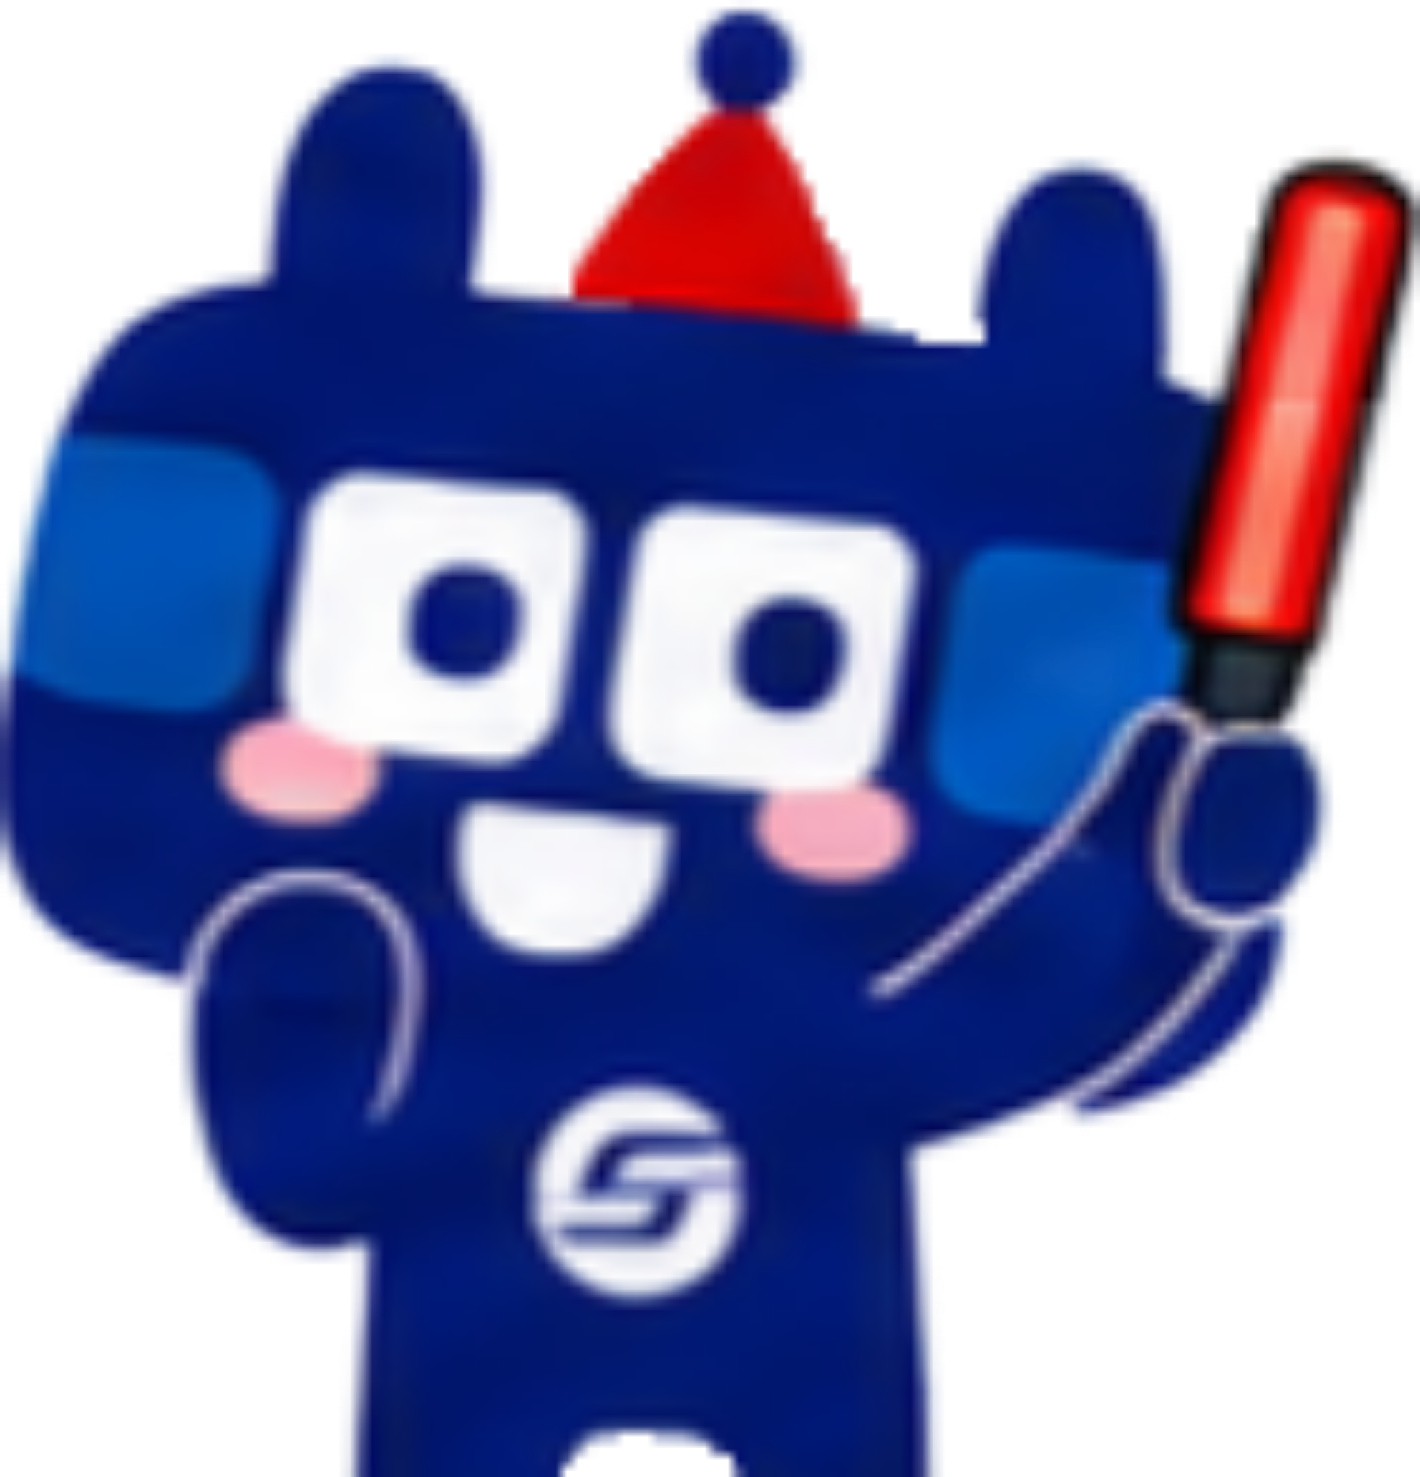
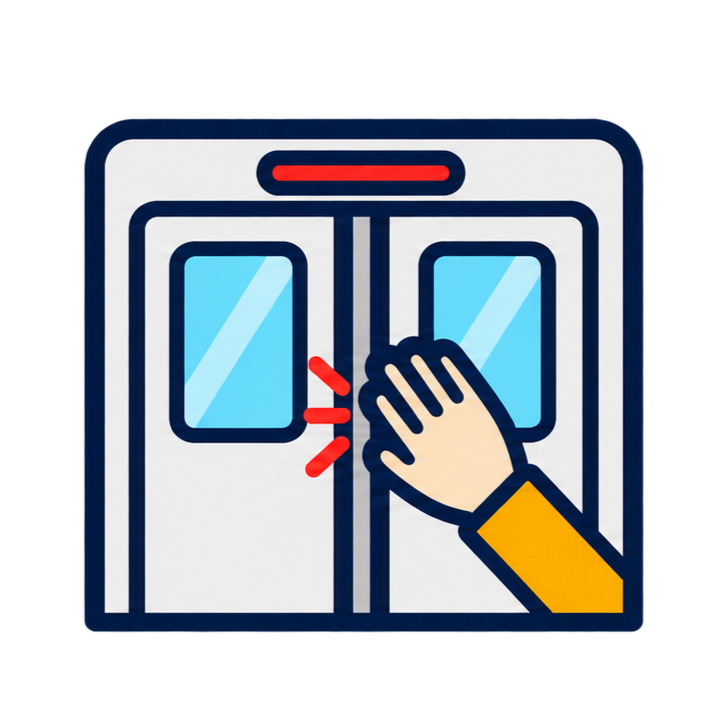
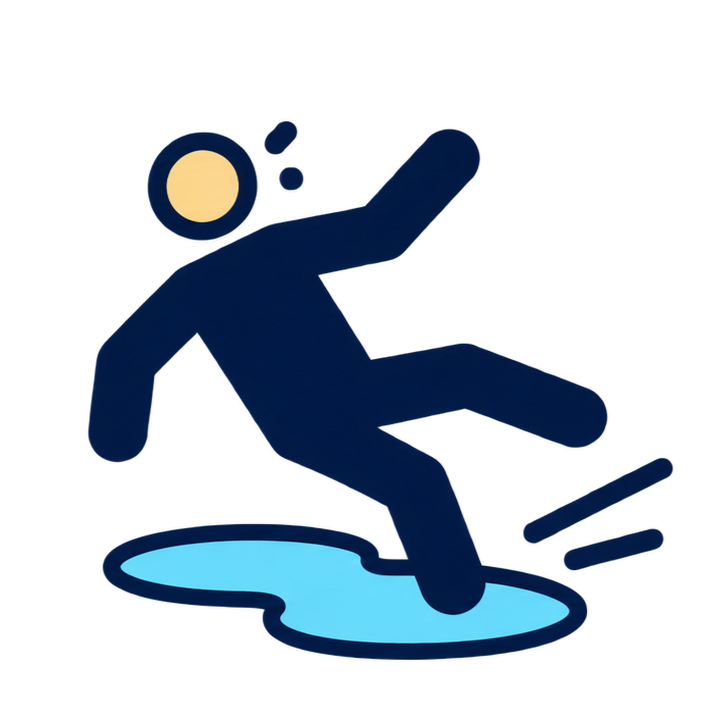
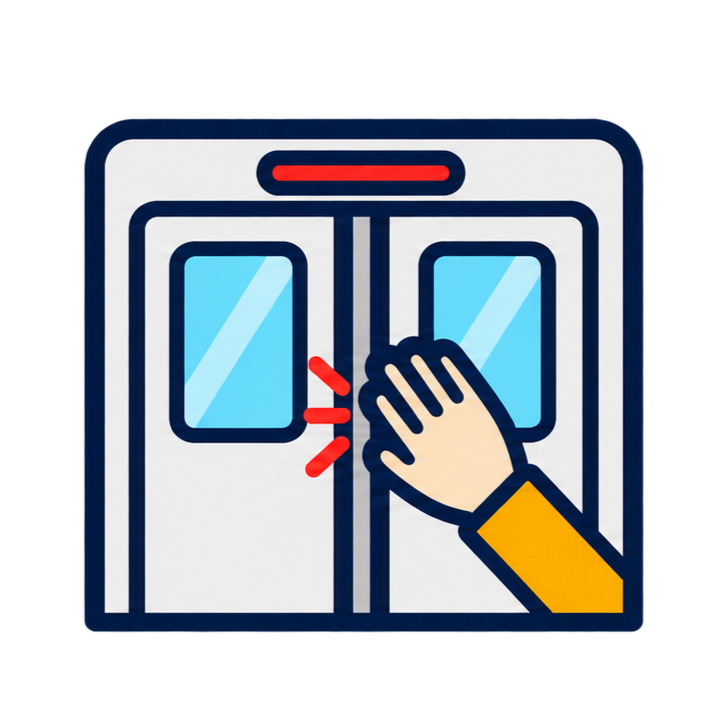
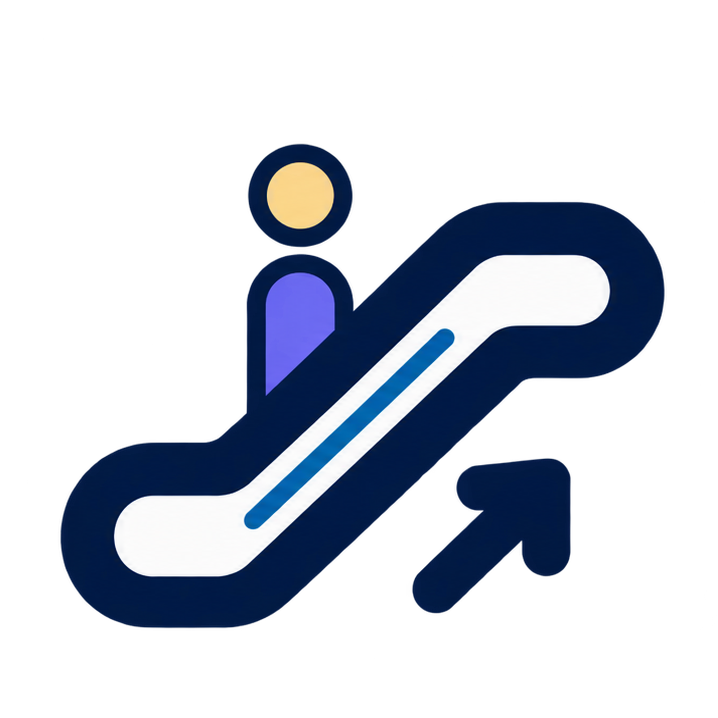
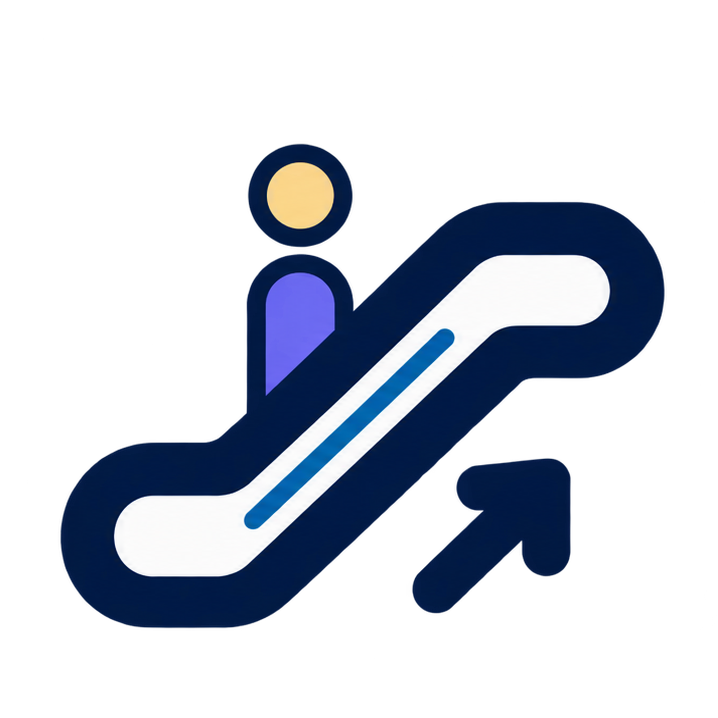
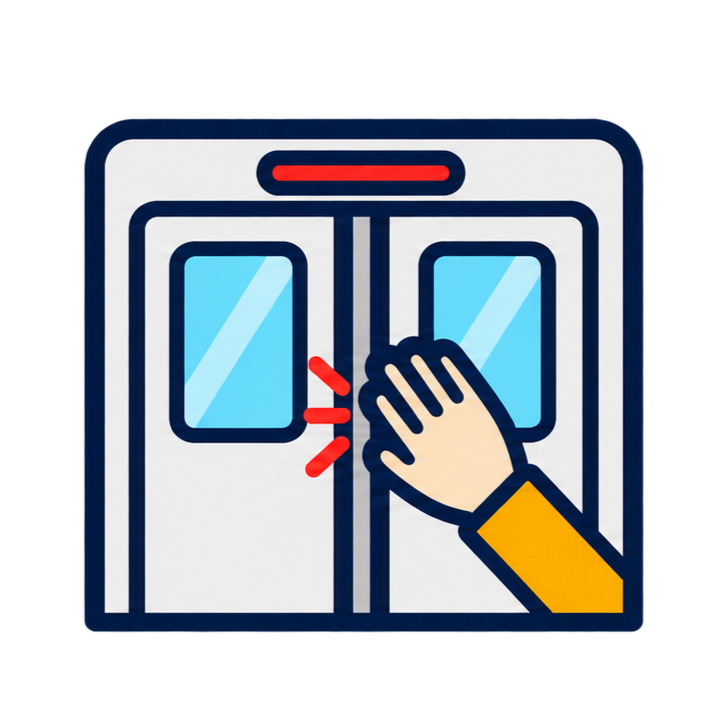
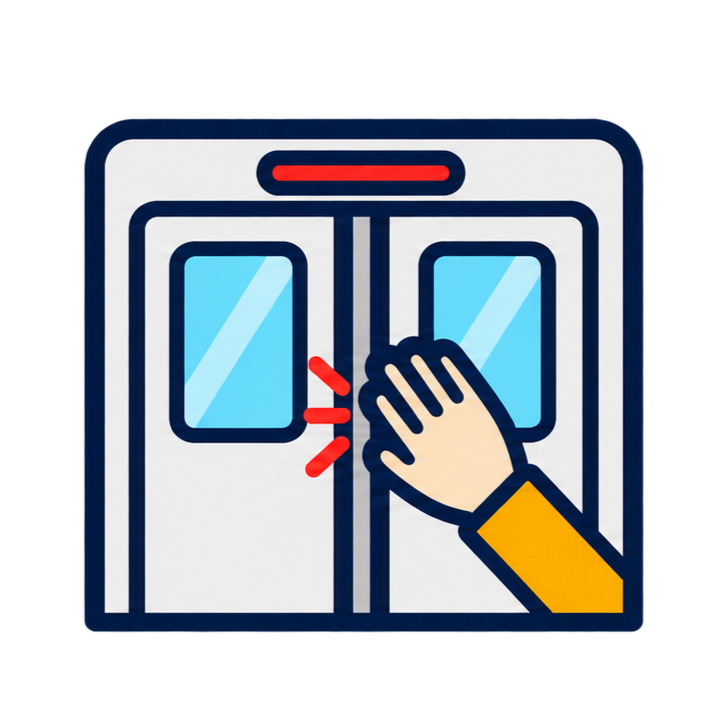
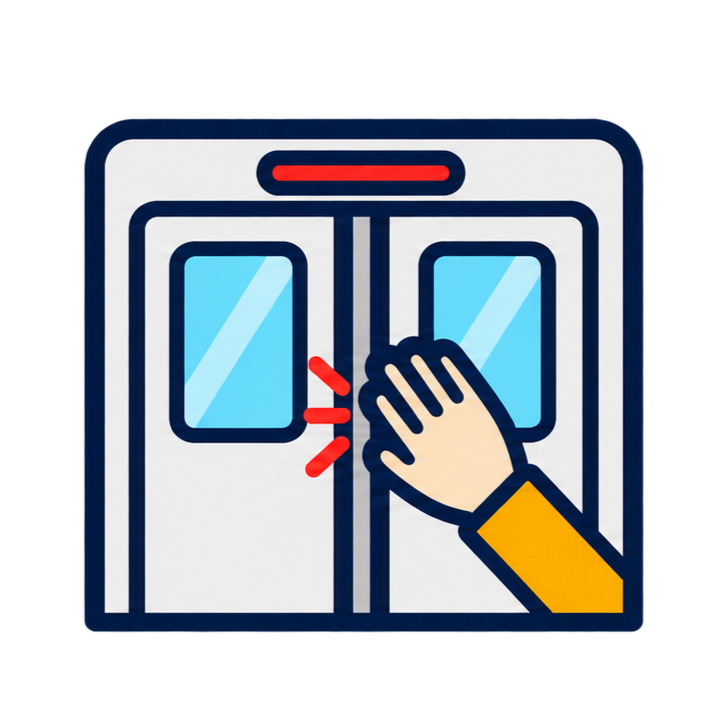
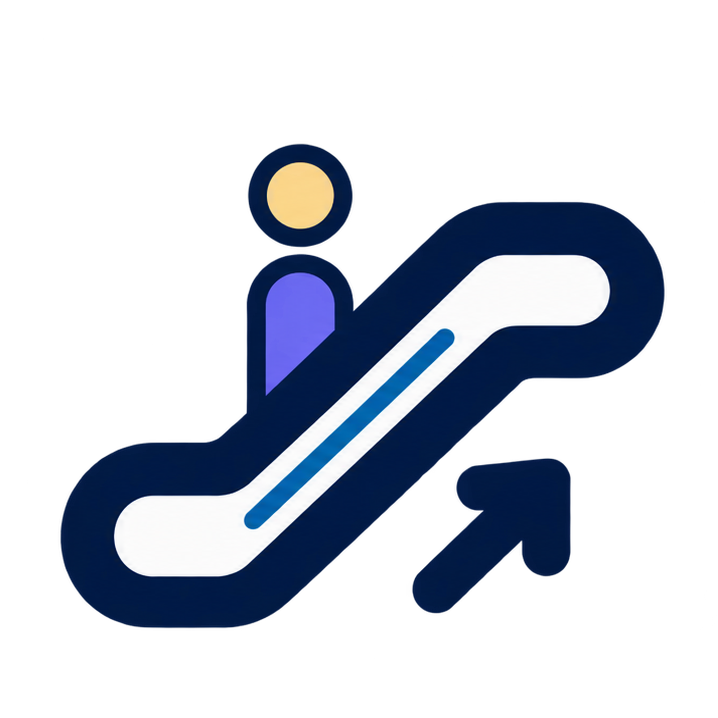
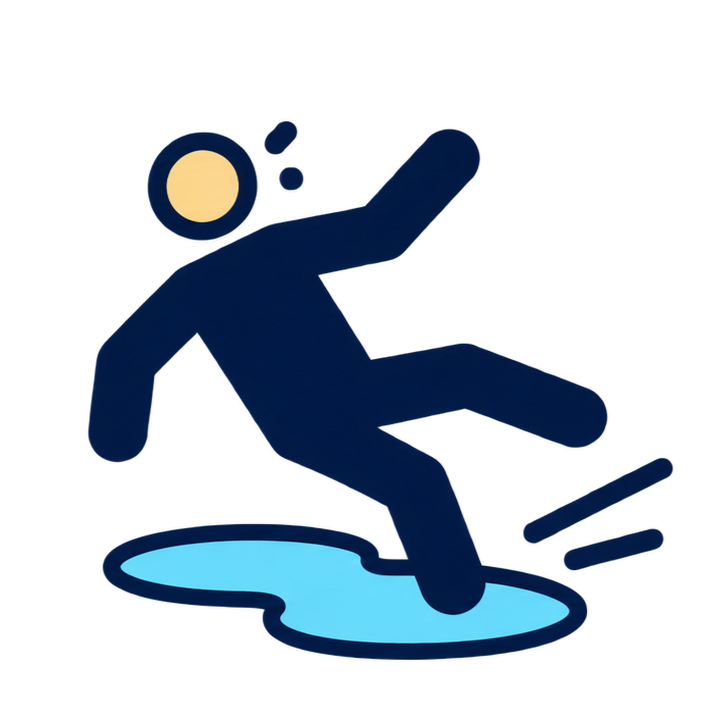
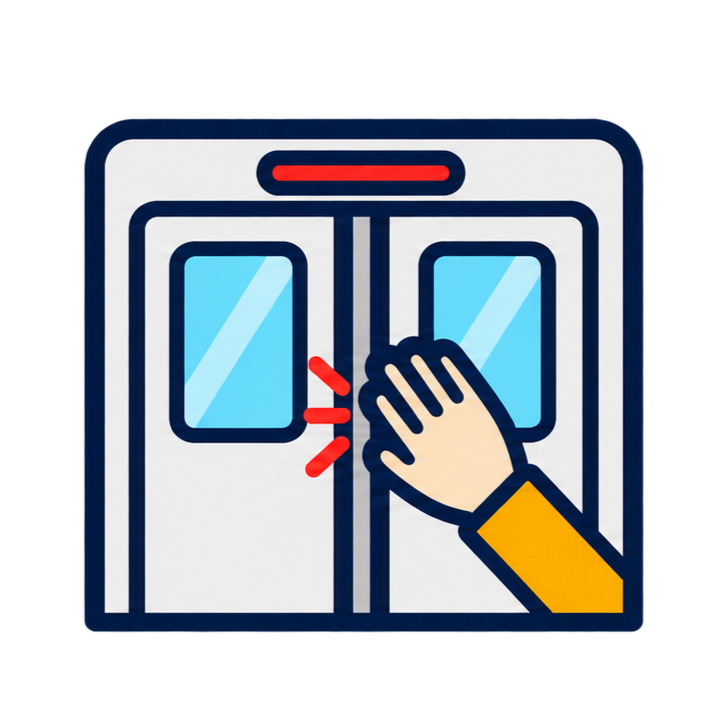
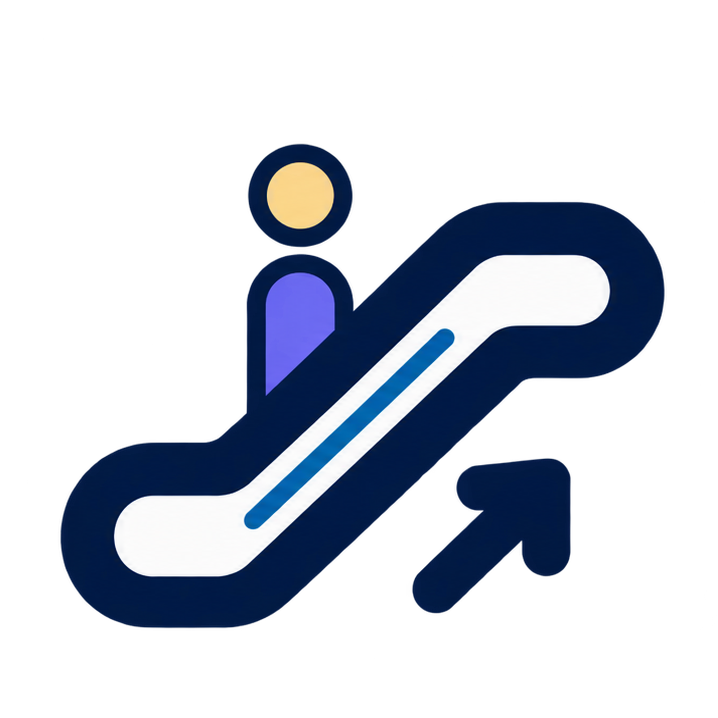
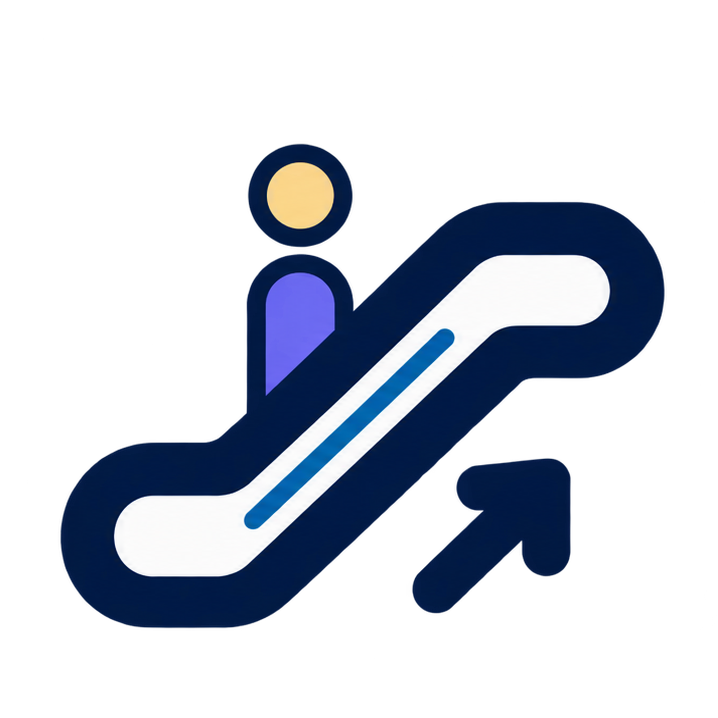
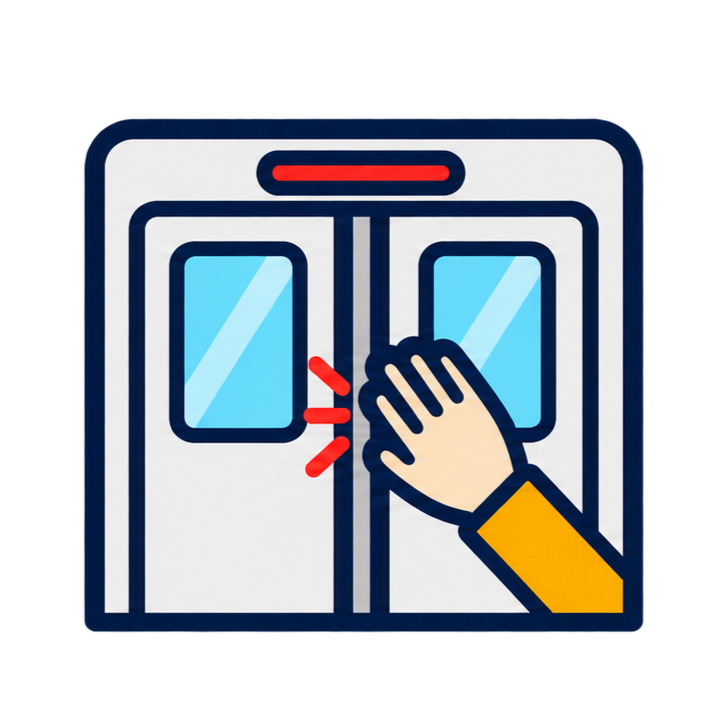
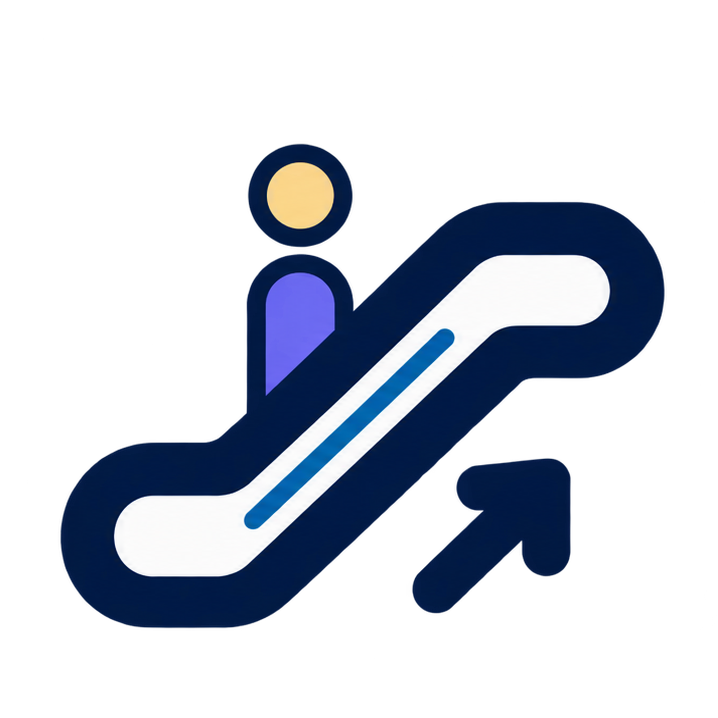
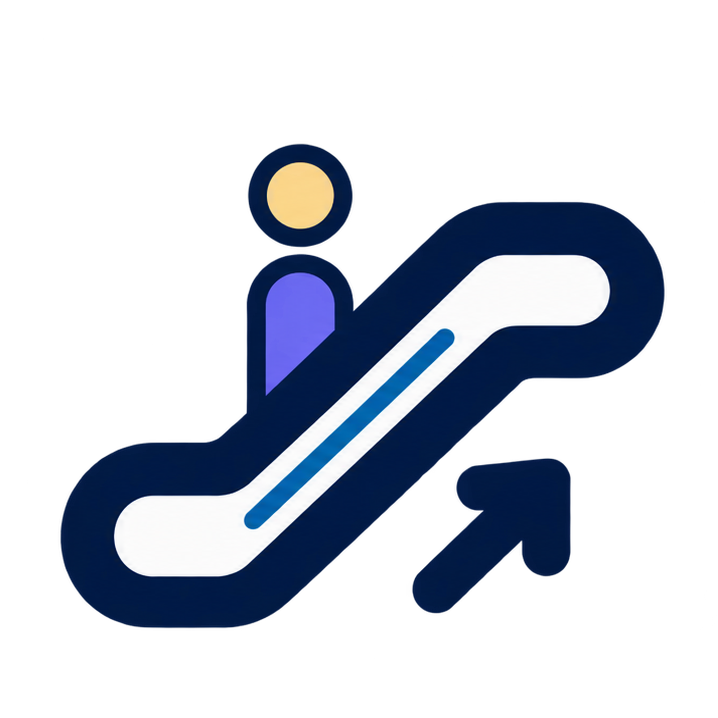
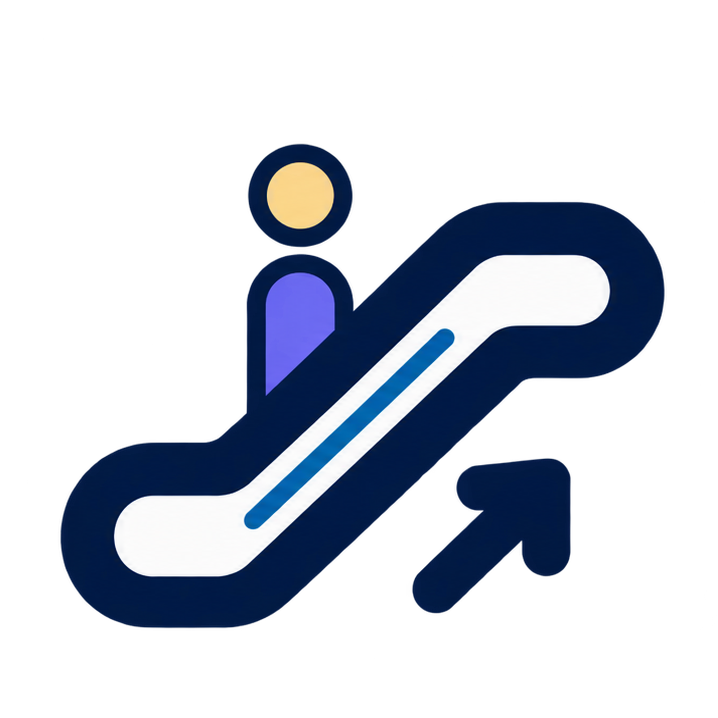
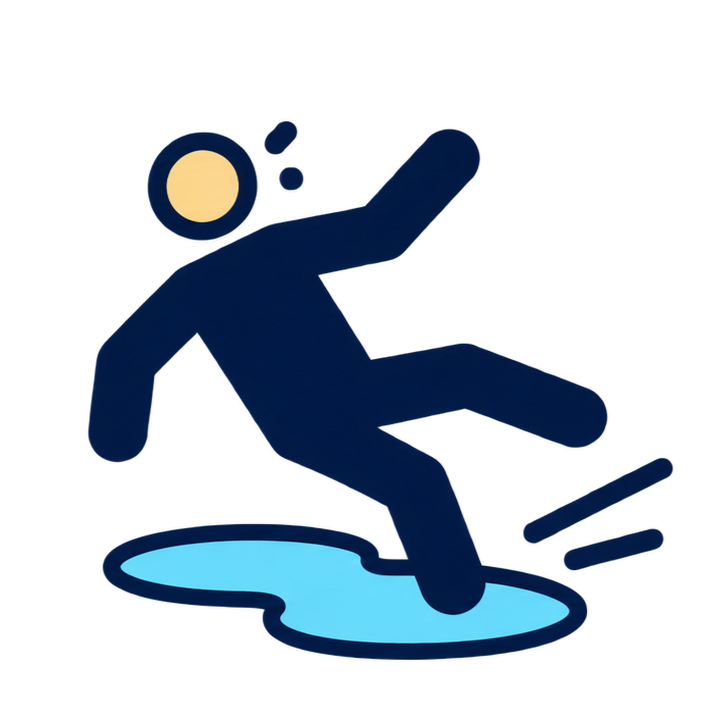
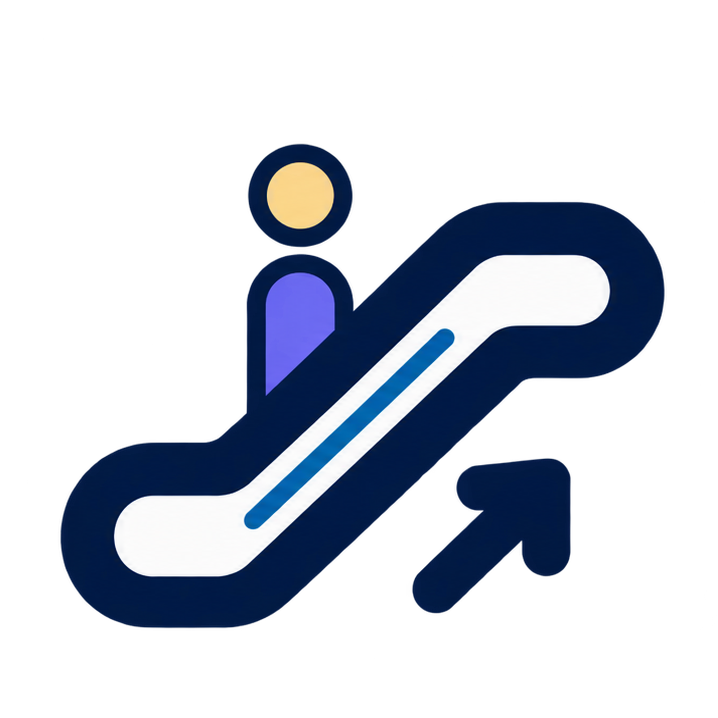
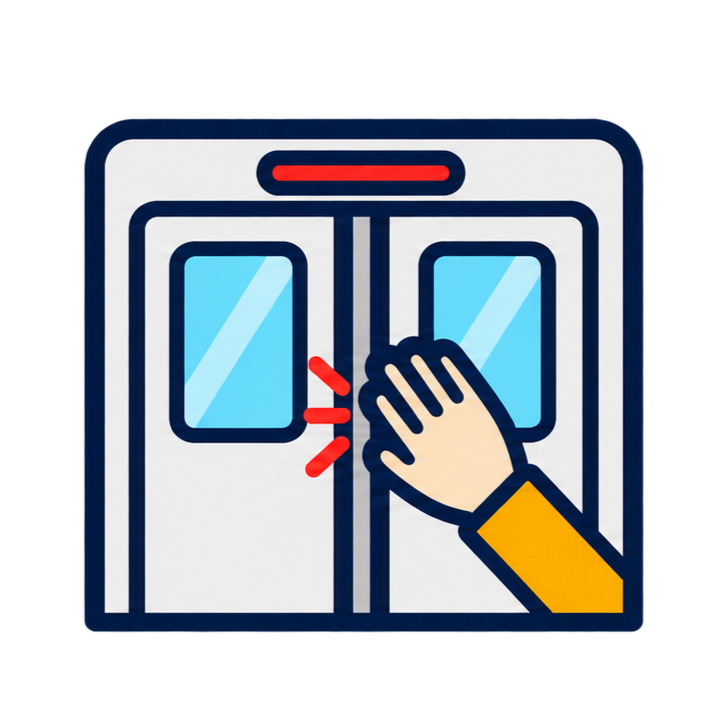

In [ ]:
# ============================================================
# 섹션 4 : 인포그래픽2 제작 (역별 위험지도)
# 아래 3개 블록(4-1, 4-2, 4-3)을 각각 별도의 코랩 코드 셀에 붙여넣으세요.
# ※ 섹션 1을 먼저 실행해서 data_info1, data_info2가 만들어진 상태여야 합니다.
# ============================================================


# ------------------------------------------------------------
# 4-1. 이미지 데이터 (사고유형 아이콘 3개 + 마스코트)
# ------------------------------------------------------------
# 깃허브 공개 저장소(Gangdong-infographic26)의 메인 브랜치 루트에 있는
# 이미지 파일을 직접 가져와서 Base64 데이터로 변환합니다.
# 코랩에 파일을 업로드할 필요가 없고, 이미지를 바꾸고 싶으면
# 깃허브에 새 파일만 올리면 됩니다 (코드 수정 불필요).
#
# 필요한 파일 (저장소 루트, 별도 폴더 없이):
#   ES사고.png
#   넘어짐.png
#   출입문끼임.png
#   마스코트.png
# ------------------------------------------------------------

import requests
import base64
from urllib.parse import quote

저장소_주소 = "https://raw.githubusercontent.com/tndhrthwls12/Gangdong-infographic26/main"

이미지_파일명 = {
    "E/S사고": "ES사고.png",
    "넘어짐": "넘어짐.png",
    "출입문끼임": "출입문끼임.png",
}
마스코트_파일명 = "마스코트.png"


def _이미지_데이터URL(파일명):
    주소 = f"{저장소_주소}/{quote(파일명)}"
    응답 = requests.get(주소, timeout=10)
    if 응답.status_code != 200:
        raise FileNotFoundError(
            f"\n이미지를 가져오지 못했습니다: {주소}\n"
            f"(상태코드 {응답.status_code}) 파일명과 저장소 경로가 정확한지 확인해주세요."
        )
    이미지_base64 = base64.b64encode(응답.content).decode("utf-8")
    return f"data:image/png;base64,{이미지_base64}"


# ------------------------------------------------------------
# 사고유형 아이콘 + 마스코트 불러오기
# ------------------------------------------------------------
아이콘_base64 = {유형: _이미지_데이터URL(파일명) for 유형, 파일명 in 이미지_파일명.items()}
마스코트_이미지 = _이미지_데이터URL(마스코트_파일명)


# ------------------------------------------------------------
# 정상적으로 이미지가 로드되었는지 확인
# ------------------------------------------------------------
print("4-1 준비 완료: 깃허브에서 이미지 데이터를 불러왔습니다.")
print()
print("로드된 이미지:")
for 유형, 파일명 in 이미지_파일명.items():
    print(f"  - {유형} ({파일명})")
print(f"  - 마스코트 ({마스코트_파일명})")


# ------------------------------------------------------------
# 4-2. 스타일 설정 + 인포그래픽2 HTML을 만드는 함수 정의
# data_info2(역별 데이터) + data_info1(대상 기간 계산용)을 받아서
# 정해진 양식대로 채워진 HTML 코드를 만듭니다.
# ------------------------------------------------------------

# 위험등급별 배지 색상 (배경색, 글자색) - 인포그래픽1과 색 규칙이 다릅니다
등급_배지_색상 = {
    '매우높음': ('#D32F2F', '#ffffff'),
    '높음':     ('#ED7D31', '#ffffff'),
    '보통':     ('#FFC000', '#333333'),
    '낮음':     ('#548235', '#ffffff'),
}

요일_약자 = {'월요일': '월', '화요일': '화', '수요일': '수', '목요일': '목',
          '금요일': '금', '토요일': '토', '일요일': '일'}


def 역카드_HTML(역):
    """역 카드 하나(헤더: 역명+위험등급 / 본문: 아이콘+정보 / 하단: 위험요인)를 만듭니다."""
    배지색, 배지글자색 = 등급_배지_색상.get(역['위험등급'], ('#9E9E9E', '#fff'))
    아이콘 = 아이콘_base64.get(역['사고유형'], '')
    요일약자 = 요일_약자.get(역['요일'], 역['요일'])
    줄2 = f"<li>{역['위험요인_줄2']}</li>" if 역['위험요인_줄2'] else ''

    return f"""
    <div class=\"station-card\">
      <div class=\"card-header\">
        <div class=\"name-cell\">{역['역명']}역</div>
        <div class=\"risk-cell\" style=\"background:{배지색}; color:{배지글자색}\">{역['위험등급']}</div>
      </div>
      <div class=\"card-main\">
        <div class=\"icon-cell\"><img class=\"type-icon\" src=\"{아이콘}\"></div>
        <div class=\"info-cell\">
          <div class=\"score-line\">위험도 {역['위험점수']:.1f}점</div>
          <div class=\"type-line\">{역['사고유형']}</div>
          <div class=\"time-line\">{요일약자}요일 ({역['시간대']}시)</div>
        </div>
      </div>
      <hr>
      <ul class=\"reason-list\">
        <li>{역['위험요인_줄1']}</li>
        {줄2}
      </ul>
    </div>"""


def _가이드박스_HTML():
    """'주요 사고 유형별 안전 행동 가이드' 칸 - 내용이 고정된 부분입니다."""
    return f"""
    <div class=\"guide-box\">
      <div class=\"guide-title\">주요 사고 유형별 안전 행동 가이드</div>
      <div class=\"guide-columns\">
        <div class=\"guide-col\">
          <img class=\"guide-icon\" src=\"{아이콘_base64['넘어짐']}\">
          <div class=\"guide-text\">
            <div class=\"guide-col-title\">넘어짐 사고</div>
            <ul><li>바닥 확인 후 이동</li><li>미끄럼 주의 안내</li><li>혼잡 구간 주의</li></ul>
          </div>
        </div>
        <div class=\"guide-col\">
          <img class=\"guide-icon\" src=\"{아이콘_base64['E/S사고']}\">
          <div class=\"guide-text\">
            <div class=\"guide-col-title\">E/S 사고</div>
            <ul><li>손잡이 잡기</li><li>에스컬레이터 점검</li><li>러시아워 혼잡 관리</li></ul>
          </div>
        </div>
        <div class=\"guide-col\">
          <img class=\"guide-icon\" src=\"{아이콘_base64['출입문끼임']}\">
          <div class=\"guide-text\">
            <div class=\"guide-col-title\">출입문 끼임 사고</div>
            <ul><li>무리한 승차 금지</li><li>승강장 PSD 점검</li><li>승차 질서 유도</li></ul>
          </div>
        </div>
      </div>
    </div>"""


def 인포그래픽2_HTML_만들기(data_info2, data_info1):
    """data_info2(역별 데이터)와 data_info1(대상 기간 계산용)을 받아서
    완성된 인포그래픽2 HTML 문서 전체를 문자열로 반환합니다."""
    시작일 = data_info1[0]['일자']
    종료일 = data_info1[-1]['일자']

    카드들 = "".join(역카드_HTML(역) for 역 in data_info2)
    가이드박스 = _가이드박스_HTML()

    html = f"""
    <style>
      #infographic2 {{ width:1250px; margin:0 auto; background:#fff;
                       font-family: \'Malgun Gothic\', \'Apple SD Gothic Neo\', sans-serif;
                       padding:20px; box-sizing:border-box; }}
      #infographic2 .title-bar {{ padding:14px 20px; margin-bottom:0;
                   display:flex; justify-content:space-between; align-items:flex-end; }}
      #infographic2 .title-text h1 {{ font-size:34px; font-weight:900; color:#1A237E; margin:0 0 6px 0; }}
      #infographic2 .title-text .sub {{ font-size:14px; color:#333; }}
      #infographic2 .mascot {{ height:85px; width:auto; object-fit:contain; display:block; }}
      #infographic2 .grid {{ display:grid; grid-template-columns:repeat(5, 1fr); gap:10px; }}
      #infographic2 .station-card {{ border:2px solid #1A237E; border-radius:8px; overflow:hidden; }}

      #infographic2 .card-header {{ display:flex; }}
      #infographic2 .name-cell {{ flex:6; background:#1A237E; color:#fff; text-align:center;
                   font-weight:bold; font-size:18px; padding:10px 4px; }}
      #infographic2 .risk-cell {{ flex:4; text-align:center; font-weight:bold; font-size:17px; padding:10px 4px; }}

      #infographic2 .card-main {{ display:flex; padding:8px 6px; }}
      #infographic2 .icon-cell {{ flex:4; display:flex; align-items:center; justify-content:center; }}
      #infographic2 .type-icon {{ width:64px; height:64px; object-fit:contain; }}
      #infographic2 .info-cell {{ flex:6; text-align:center; display:flex; flex-direction:column; justify-content:center; }}
      #infographic2 .score-line {{ font-size:12px; color:#555; }}
      #infographic2 .type-line {{ font-size:18px; font-weight:bold; }}
      #infographic2 .time-line {{ font-size:12px; color:#555; }}

      #infographic2 .station-card hr {{ border:none; border-top:1px solid #ddd; margin:0 10px 8px 10px; }}
      #infographic2 .reason-list {{ text-align:left; font-size:12px; margin:0; padding:0 10px 10px 24px; color:#333; }}

      #infographic2 .guide-box {{ grid-column: span 3; border:2px solid #1A237E; border-radius:8px;
                   display:flex; flex-direction:column; justify-content:center; }}
      #infographic2 .guide-title {{ font-weight:bold; font-size:22px; text-align:left; padding-left:28px;
                     margin-bottom:13px; }}
      #infographic2 .guide-columns {{ display:grid; grid-template-columns:repeat(3, 1fr); padding:0 16px;
                    width:100%; box-sizing:border-box; }}
      #infographic2 .guide-col {{ display:flex; align-items:center; gap:16px; min-width:0; padding:0 8px; }}
      #infographic2 .guide-columns > .guide-col:not(:last-child) {{ border-right:1px dotted #999; }}
      #infographic2 .guide-icon {{ width:52px; height:52px; object-fit:contain; flex-shrink:0; }}
      #infographic2 .guide-text {{ text-align:left; min-width:0; white-space:nowrap; }}
      #infographic2 .guide-col-title {{ font-weight:bold; font-size:17px; margin-bottom:4px; }}
      #infographic2 .guide-col ul {{ font-size:13px; margin:0; padding-left:16px; line-height:1.7; }}
      #infographic2 .guide-col ul li {{ white-space:nowrap; }}
    </style>
    <div id=\"infographic2\">
      <div class=\"title-bar\">
        <div class=\"title-text\">
          <h1>[주간 사고 위험 예보] 안전한 지하철을 위한 역별 위험지도</h1>
          <div class=\"sub\">대상 기간 : {시작일} ~ {종료일} &nbsp;|&nbsp; 서울교통공사</div>
        </div>
        <img class=\"mascot\" src=\"{마스코트_이미지}\">
      </div>
      <div class=\"grid\">
        {카드들}
        {가이드박스}
      </div>
    </div>
    """
    return html


print("4-2 준비 완료: 인포그래픽2_HTML_만들기() 함수가 정의되었습니다.")


# ------------------------------------------------------------
# 4-3. 화면에 출력 + JPG 다운로드 버튼
# data_info2와 data_info1으로 인포그래픽2를 만들어 화면에 보여주고,
# 아래 \"JPG로 다운로드\" 버튼을 누르면 지금 화면에 보이는 모습 그대로
# 이미지 파일(JPG)로 저장됩니다.
# ------------------------------------------------------------
from IPython.display import HTML, display

인포그래픽2_내용 = 인포그래픽2_HTML_만들기(data_info2, data_info1)

다운로드_버튼_HTML2 = """
<div style=\"width:1250px; margin:0 auto; text-align:center; padding-bottom:20px;\">
  <button onclick=\"캡처_인포그래픽2()\"
          style=\"padding:10px 24px; font-size:16px; font-weight:bold; cursor:pointer;
                 background:#1A237E; color:white; border:none; border-radius:6px;\">
    JPG로 다운로드
  </button>
</div>
<script src=\"https://cdnjs.cloudflare.com/ajax/libs/html2canvas/1.4.1/html2canvas.min.js\"></script>
<script>
function 캡처_인포그래픽2() {
    html2canvas(document.getElementById(\'infographic2\'), {scale: 2, backgroundColor: \'#ffffff\'})\
        .then(function(canvas) {
            var 링크 = document.createElement(\'a\');
            링크.download = \'인포그래픽2.jpg\';
            링크.href = canvas.toDataURL(\'image/jpeg\', 0.95);
            링크.click();
        });
}
</script>
"""

display(HTML(인포그래픽2_내용 + 다운로드_버튼_HTML2))